Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total Sentences Loaded: 13813


100%|██████████| 1000/1000 [08:53<00:00,  1.87it/s]



Saved: relation_wise_accuracy.csv

BEST HEAD PER RELATION

Relation: nsubj
Relation       nsubj
Layer              7
Head               9
Accuracy    0.616779
Name: 800, dtype: object

Relation: obj
Relation         obj
Layer              8
Head               4
Accuracy    0.697842
Name: 951, dtype: object

Relation: det
Relation         det
Layer              6
Head               9
Accuracy    0.987337
Name: 500, dtype: object

Relation: amod
Relation        amod
Layer              7
Head               4
Accuracy    0.960192
Name: 219, dtype: object

Relation: advmod
Relation     advmod
Layer             7
Head              9
Accuracy    0.77353
Name: 80, dtype: object

Relation: case
Relation        case
Layer              6
Head               9
Accuracy    0.973133
Name: 356, dtype: object

Relation: nmod
Relation        nmod
Layer              3
Head               6
Accuracy    0.539153
Name: 605, dtype: object


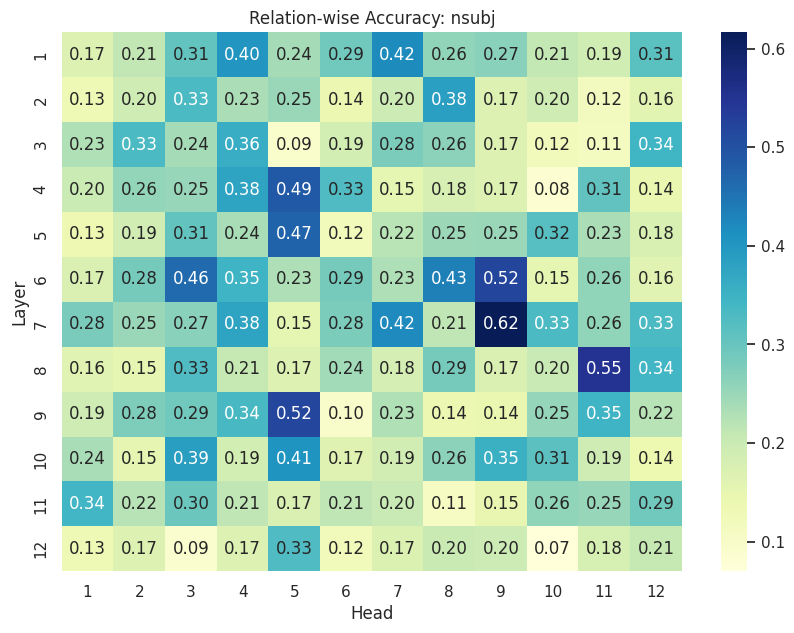

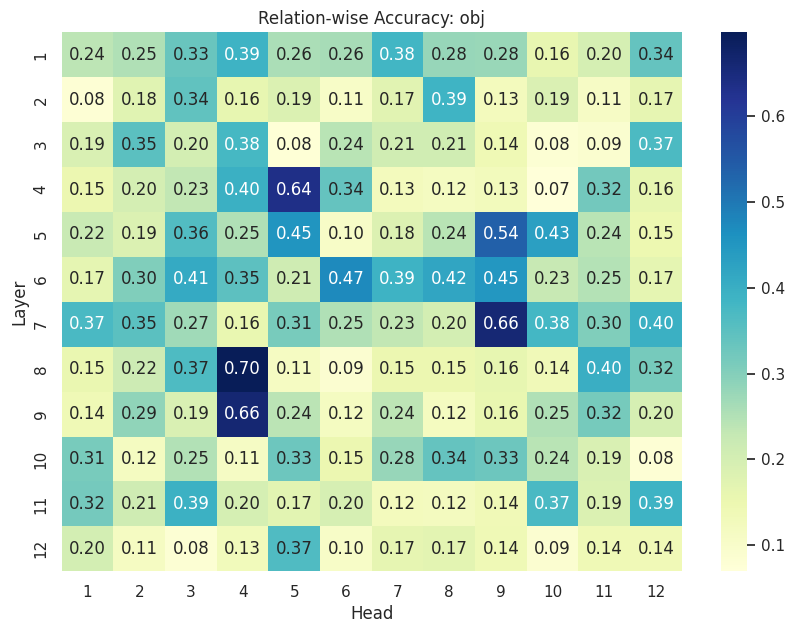

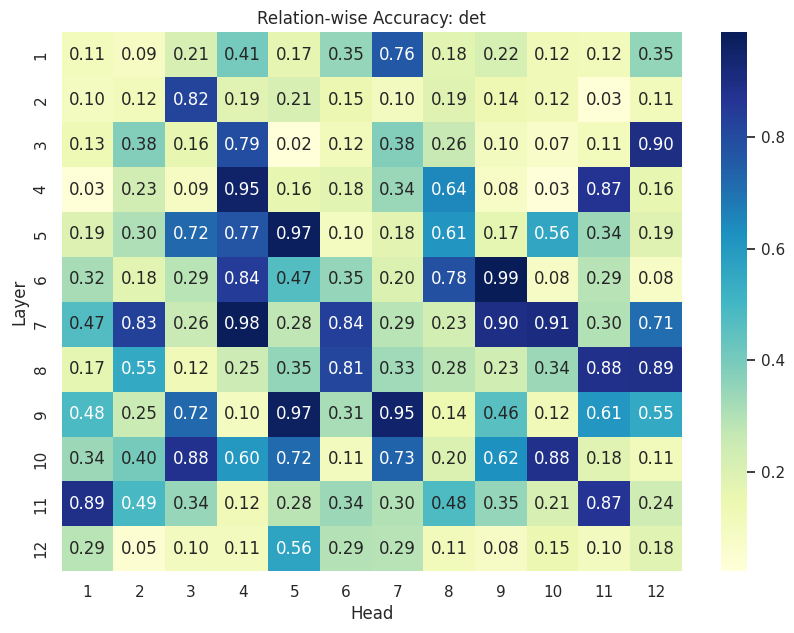

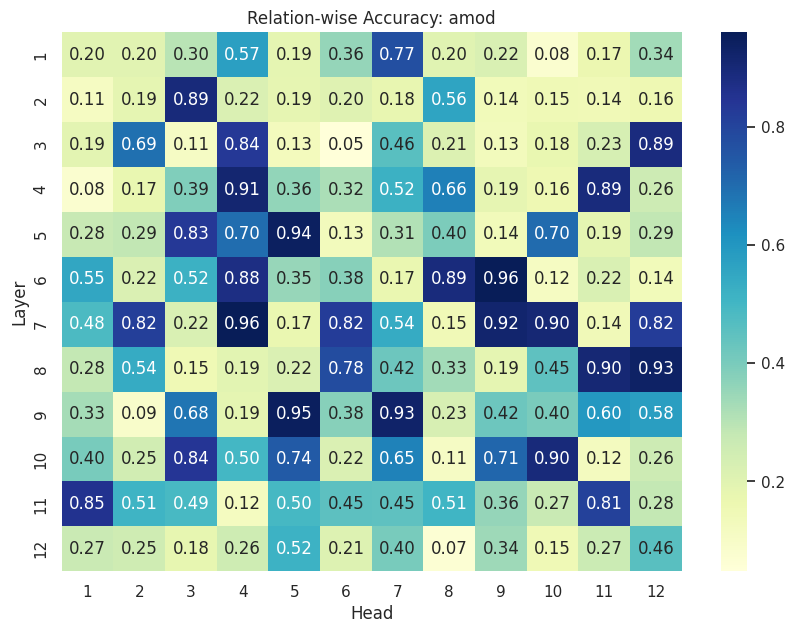

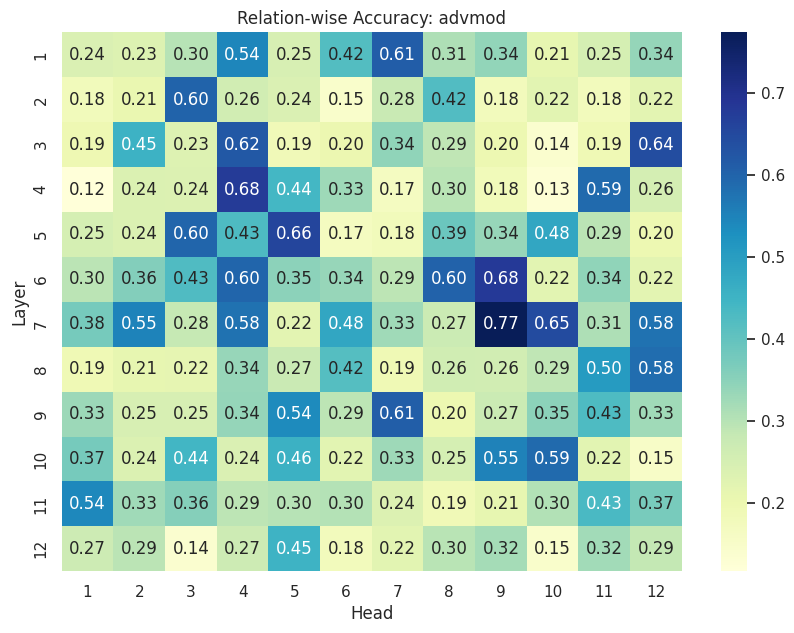

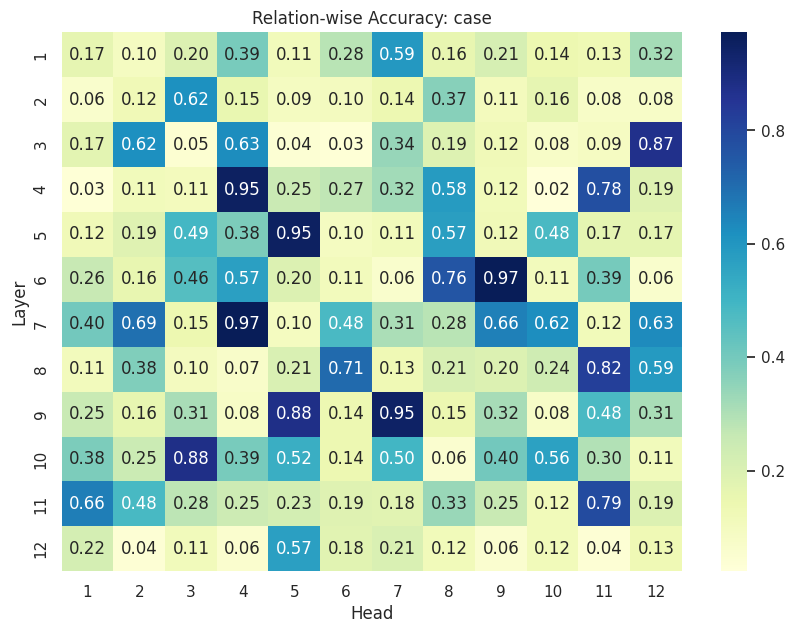

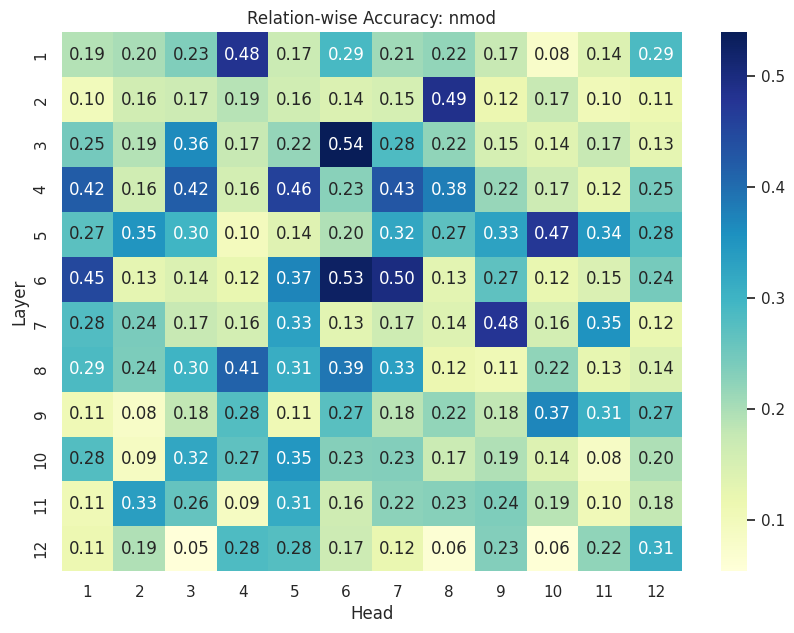

In [ ]:
# ==========================================================
# RELATION-WISE ACCURACY PIPELINE (BERT + UD DATASET)
# ----------------------------------------------------------

!pip -q install transformers torch conllu requests seaborn matplotlib pandas numpy tqdm


import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests

from tqdm import tqdm
from conllu import parse
from transformers import BertTokenizer, BertModel

sns.set(style="whitegrid")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


MODEL_NAME = "bert-base-multilingual-cased"


DATASET_URL = "https://raw.githubusercontent.com/UniversalDependencies/UD_German-GSD/master/de_gsd-ud-train.conllu"
NUM_SENTENCES = 1000
MAX_LEN_WORDS = 40


TARGET_RELATIONS = [
    "nsubj", "obj", "iobj", "det",
    "amod", "advmod", "case", "nmod"
]


tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

model = BertModel.from_pretrained(
    MODEL_NAME,
    output_attentions=True
)

model.to(device)
model.eval()


print("Downloading dataset...")
data = requests.get(DATASET_URL).text
sentences = parse(data)

print("Total Sentences Loaded:", len(sentences))


def tokenize_with_alignment(words):

    bert_tokens = ["[CLS]"]
    mapping = {}

    pos = 1

    for i, word in enumerate(words, start=1):

        sub_tokens = tokenizer.tokenize(word)

        if len(sub_tokens) == 0:
            sub_tokens = ["[UNK]"]

        mapping[i] = list(range(pos, pos + len(sub_tokens)))

        bert_tokens.extend(sub_tokens)
        pos += len(sub_tokens)

    bert_tokens.append("[SEP]")

    return bert_tokens, mapping



def get_attention(words):

    sent = " ".join(words)

    inputs = tokenizer(
        sent,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {k:v.to(device) for k,v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    return outputs.attentions



def convert_to_word_matrix(token_matrix, mapping, n_words):

    word_matrix = np.zeros((n_words+1, n_words+1))

    for child in range(1, n_words+1):

        child_tokens = mapping[child]

        for parent in range(1, n_words+1):

            parent_tokens = mapping[parent]

            vals = []

            for ct in child_tokens:
                for pt in parent_tokens:
                    vals.append(token_matrix[ct][pt])

            word_matrix[child][parent] = np.mean(vals)

    return word_matrix



def relation_score(word_matrix, heads, rels, target_relation):

    correct = 0
    total = 0
    n = len(heads)

    for child in range(1, n+1):

        if rels[child-1] != target_relation:
            continue

        gold_parent = heads[child-1]

        if gold_parent == 0:
            continue

        row = word_matrix[child][1:]  
        top3 = np.argsort(row)[-3:] + 1

        if gold_parent in top3:
            correct += 1

        total += 1

    if total == 0:
        return None

    return correct / total



results = []

for idx in tqdm(range(min(NUM_SENTENCES, len(sentences)))):

    try:
        sent = sentences[idx]

        words = []
        heads = []
        rels  = []

        for tok in sent:

            if isinstance(tok["id"], int):
                words.append(tok["form"])
                heads.append(tok["head"])
                rels.append(tok["deprel"])

        if len(words) < 3:
            continue

        if len(words) > MAX_LEN_WORDS:
            continue

        attentions = get_attention(words)

        _, mapping = tokenize_with_alignment(words)

        n_words = len(words)

        for layer in range(12):
            for head in range(12):

                token_matrix = attentions[layer][0, head].cpu().numpy()

                word_matrix = convert_to_word_matrix(
                    token_matrix,
                    mapping,
                    n_words
                )

                for rel in TARGET_RELATIONS:

                    score = relation_score(
                        word_matrix,
                        heads,
                        rels,
                        rel
                    )

                    if score is not None:
                        results.append([
                            rel,
                            layer+1,
                            head+1,
                            score
                        ])

    except:
        continue


df = pd.DataFrame(
    results,
    columns=["Relation", "Layer", "Head", "Accuracy"]
)


avg_df = df.groupby(
    ["Relation", "Layer", "Head"]
)["Accuracy"].mean().reset_index()


avg_df.to_csv("relation_wise_accuracy.csv", index=False)

print("\nSaved: relation_wise_accuracy.csv")

print("\n==============================")
print("BEST HEAD PER RELATION")
print("==============================")

for rel in TARGET_RELATIONS:

    sub = avg_df[avg_df["Relation"] == rel]

    if len(sub) == 0:
        continue

    best = sub.sort_values(
        "Accuracy",
        ascending=False
    ).iloc[0]

    print(f"\nRelation: {rel}")
    print(best)


for rel in TARGET_RELATIONS:

    sub = avg_df[avg_df["Relation"] == rel]

    if len(sub) == 0:
        continue

    pivot = sub.pivot(
        index="Layer",
        columns="Head",
        values="Accuracy"
    )

    plt.figure(figsize=(10,7))

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu"
    )

    plt.title(f"Relation-wise Accuracy: {rel}")
    plt.xlabel("Head")
    plt.ylabel("Layer")

    plt.show()